Import pickle to load saved machine learning models.


In [1]:
import pickle


Open and load the saved machine learning model.


In [2]:
ml_model_file = open("ml_model.pkl", "rb")
ml_model = pickle.load(ml_model_file)
ml_model_file.close()


c:\Users\PC\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Import pandas to read and handle the dataset.


In [3]:
import pandas as pd


Read the heart disease dataset.


In [4]:
df = pd.read_csv("heart_dataset.csv")


Select all feature columns up to `thallium_heart_rate`.


In [5]:
dataset_features = df.loc[:, :"thallium_heart_rate"]


Store the feature names in a list.


In [6]:
feature_names = dataset_features.columns.to_list()


Get all decision trees from the random forest model.


In [7]:
decision_trees = ml_model.estimators_


Print the number of decision trees.


In [8]:
print(len(decision_trees))


100


Select the first decision tree for visualization.


In [9]:
decision_tree = decision_trees[0]


Import `plot_tree` to visualize decision trees.


In [10]:
from sklearn.tree import plot_tree


Plot the full decision tree.


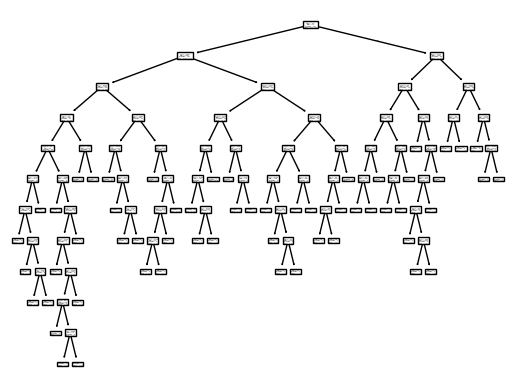

In [11]:
_ = plot_tree(decision_tree)


Plot only the first two levels of the decision tree with feature names.


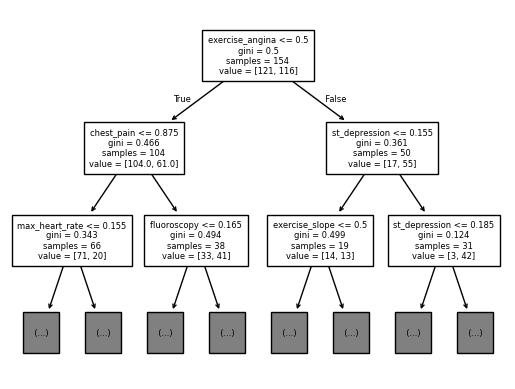

In [12]:
_ = plot_tree(
    decision_tree,
    max_depth=2,
    feature_names=feature_names,
    fontsize=6
)


Open and load the saved deep learning model.


In [13]:
dl_model_file = open("dl_model.pkl", "rb")
dl_model = pickle.load(dl_model_file)
dl_model_file.close()


Convert the dataset features into a NumPy array.


In [14]:
dataset_features = dataset_features.to_numpy()


Select the first sample from the dataset.


In [15]:
one_sample_features = dataset_features[0]


Import PyTorch to convert NumPy arrays into tensors.


In [16]:
import torch


Wrap the deep learning model so SHAP can call it using NumPy input.


In [17]:
dl_model_wrapped = lambda features: dl_model(
    torch.Tensor(features)
).detach().numpy()


Import `tqdm` and SHAP for model explanation.


In [18]:
import tqdm.auto
import shap


Create a SHAP KernelExplainer using the first 100 samples as background data.


In [19]:
shap_explainer = shap.KernelExplainer(
    dl_model_wrapped,
    dataset_features[:100]
)


Get the expected/base prediction value from SHAP.


In [20]:
shap_expected_value = shap_explainer.expected_value


Calculate SHAP values for one sample.


In [21]:
one_sample_shap_values = shap_explainer.shap_values(one_sample_features)


Print the SHAP values for the selected sample.


In [22]:
print(one_sample_shap_values)


[[-0.01682188]
 [ 0.02345147]
 [-0.14076494]
 [ 0.        ]
 [ 0.        ]
 [-0.13827236]
 [ 0.03291453]
 [ 0.        ]
 [-0.04447937]
 [ 0.06287743]
 [ 0.07561273]
 [-0.14626231]
 [ 0.06270014]]


Import Matplotlib to display SHAP plots.


In [23]:
import matplotlib.pyplot as plt


Create a force plot to explain the prediction for one sample.


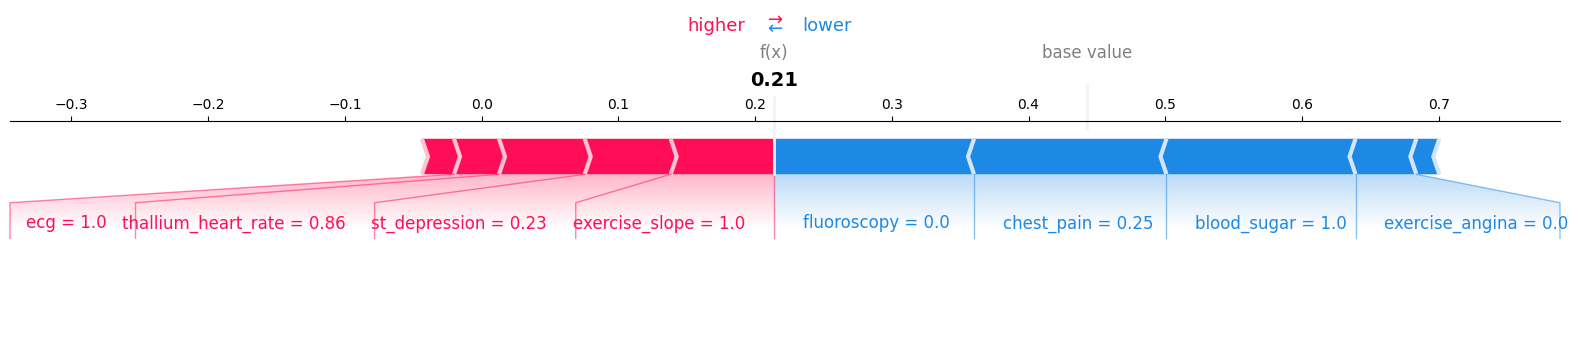

In [24]:
single_shap_values = one_sample_shap_values.flatten()

shap.force_plot(
    shap_expected_value[0],
    single_shap_values,
    one_sample_features,
    feature_names=feature_names,
    matplotlib=True,
    show=True
)

Select the first 10 samples for a summary explanation.


In [25]:
multiple_samples_features = dataset_features[:10]


Calculate SHAP values for the first 10 samples.


In [26]:
multiple_samples_shap_values = shap_explainer.shap_values(
    multiple_samples_features
)


  0%|          | 0/10 [00:00<?, ?it/s]

Create a summary plot showing feature importance across multiple samples.


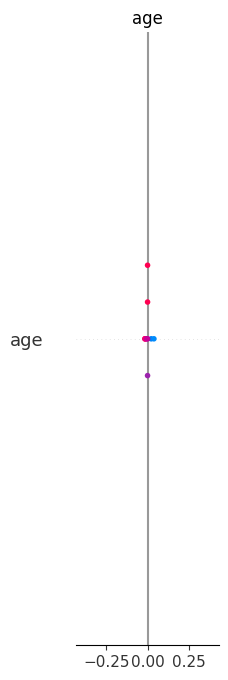

In [27]:
shap.summary_plot(
    multiple_samples_shap_values,
    multiple_samples_features,
    feature_names=feature_names
)
